In [1]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

In [2]:
def str2num(txt):
    try:
        txt = re.sub('[^0-9,]', '', txt)
        txt = re.sub(',', '.', txt)
        return float(txt)
    except TypeError:
        return np.nan


def split_adress(row):
    txt = re.sub('На карте', '', row['Адрес'])
    words = txt.split(', ')
    if len(words) == 4:
        try:
            num = re.findall(r'^\d+', words[3])[0]
            letter = words[3][len(num):]
            return words[0], words[1], None, words[2], int(num), letter
        except:
            return words[0], words[1], words[2], words[3], np.nan, ''
    if len(words) == 5:
        num = re.findall(r'^\d+', words[4])[0]
        letter = words[4][len(num):]
        return words[0], words[1], words[2], words[3], int(num), letter
    if len(words) == 6:
        num = re.findall(r'^\d+', words[5])[0]
        letter = words[5][len(num):]
        return words[0], words[1], words[2], ', '.join([words[3], words[4]]), int(num), letter


train = pd.read_csv('cian_train.csv', index_col=0)

train['Цена'] = train['Цена'].apply(lambda x: str2num(x))
train['Общая площадь'] = train['Общая площадь'].apply(lambda x: str2num(x))
train['Площадь кухни'] = train['Площадь кухни'].apply(lambda x: str2num(x))
train['Высота потолков'] = train['Высота потолков'].apply(lambda x: str2num(x))
train['Жилая площадь'] = train['Жилая площадь'].apply(lambda x: str2num(x))

train['Этаж'] = train['Этаж'].apply(lambda x: int(x.split()[0]))

train[['Область', 'Город', 'Район', 'Улица', 'Номер дома', 'Корпус']] = train.apply(split_adress, axis=1, result_type="expand")

def get_first_num(txt):
    txt = re.sub('[^0-9]', ' ', txt)
    txt = re.sub('\+ ', ' ', txt)
    txt = txt.strip()
    num = int(txt.split(' ')[0])
    if num > 10:
        num = 1
    return num

train['Количество комнат'] = train['Имя'].apply(lambda x: get_first_num(x))

train['Санузел'].fillna('Не указано', inplace=True)
train['Вид из окон'].fillna('Не указано', inplace=True)
train['Ремонт'].fillna('Не указано', inplace=True)
train['Строительная серия'].fillna('Не указано', inplace=True)
train['Тип дома'].fillna('Не указано', inplace=True)
train['Тип перекрытий'].fillna('Не указано', inplace=True)
train['Отопление'].fillna('Не указано', inplace=True)
train['Аварийность'].fillna('Не указано', inplace=True)
train['Парковка'].fillna('Не указано', inplace=True)
train['Балкон/лоджия'].fillna('Не указано', inplace=True)
train['Район'].fillna('Не указано', inplace=True)

print(train.isna().sum())

train

Имя                      0
Ссылка                   0
Цена                     0
Адрес                    0
Описание                 0
Общая площадь            0
Площадь кухни           69
Этаж                     0
Год постройки           32
Тип жилья                0
Высота потолков        331
Санузел                  0
Вид из окон              0
Ремонт                   0
Строительная серия       0
Тип дома                 0
Тип перекрытий           0
Подъезды                51
Отопление                0
Аварийность              0
Обременения            417
Кадастровый номер      417
Площадь                417
Тип помещения          417
Парковка                 0
Собственников          419
Жилая площадь          371
Мусоропровод           431
Продаётся с мебелью    430
Балкон/лоджия            0
Количество лифтов      413
Газоснабжение          482
Размер доли            486
Область                  0
Город                    0
Район                    0
Улица                    0
Н

C:\Users\Dalabis\AppData\Local\Temp\ipykernel_18136\1230780414.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Санузел'].fillna('Не указано', inplace=True)
C:\Users\Dalabis\AppData\Local\Temp\ipykernel_18136\1230780414.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

,Имя,Ссылка,Цена,Адрес,Описание,Общая площадь,Площадь кухни,Этаж,Год постройки,Тип жилья,...,Количество лифтов,Газоснабжение,Размер доли,Область,Город,Район,Улица,Номер дома,Корпус,Количество комнат
0,"2-комн. квартира, 45,9 м², 1/2 этаж",https://kemerovo.cian.ru/sale/flat/309364361/,1600000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Продаётся 2-комнатная квартира. Есть вся необх...,45.9,5.0,1,1958.0,Вторичка,...,NaN,NaN,NaN,Кемеровская область,Прокопьевск,р-н Центральный,Союзная ул.,22.0,,2
1,"2-комн. квартира, 43,4 м², 1/5 этаж",https://kemerovo.cian.ru/sale/flat/305564238/,3300000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...","Продам квартиру, комнаты изолированные. 1 этаж...",43.4,5.3,1,1972.0,Вторичка,...,NaN,NaN,NaN,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Обручева,17.0,,2
2,просторная 4к с большой прихожей,https://kemerovo.cian.ru/sale/flat/300926183/,5500000.0,"Кемеровская область, Прокопьевск, р-н Централь...","Прeдлагаем к пpoдаже простoрную,cветлую и тeп...",86.0,8.9,2,1982.0,Вторичка,...,NaN,NaN,NaN,Кемеровская область,Прокопьевск,р-н Центральный,Союзная ул.,67.0,,4
3,"1-комн. квартира, 26 м², 3/3 этаж",https://kemerovo.cian.ru/sale/flat/314127343/,1350000.0,"Кемеровская область, Прокопьевск, р-н Зенковск...","Продается квартира в Зенковском районе,Красный...",26.0,6.0,3,1963.0,Вторичка,...,NaN,NaN,NaN,Кемеровская область,Прокопьевск,р-н Зенковский,ул. Черных,20.0,,1
4,2-к. квартира у Школы 71,https://kemerovo.cian.ru/sale/flat/310728535/,1850000.0,"Кемеровская область, Прокопьевск, р-н Централь...",Собственник. Торг. Продаётся уютная 2-к кварти...,41.5,5.6,2,NaN,Вторичка,...,NaN,NaN,NaN,Кемеровская область,Прокопьевск,р-н Центральный,Ясная Поляна микрорайон,NaN,,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,"4-комн. квартира, 82,4 м², 7/9 этаж",https://kemerovo.cian.ru/sale/flat/313806030/,6500000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...","Светлая,очень теплая.Рядом 32 школа, детсад, ф...",82.4,9.0,7,2000.0,Вторичка,...,1 пассажирский,NaN,NaN,Кемеровская область,Прокопьевск,р-н Рудничный,ул. Гайдара,18.0,,4
483,"4-комн. квартира, 89 м², 2/9 этаж",https://kemerovo.cian.ru/sale/flat/314089119/,7000000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",Продам 4х комнатную мебелированную квартиру. П...,89.0,9.0,2,1984.0,Вторичка,...,1 пассажирский,NaN,NaN,Кемеровская область,Прокопьевск,р-н Рудничный,просп. Строителей,27.0,,4
484,"4-комн. квартира, 90 м², 10/10 этаж",https://kemerovo.cian.ru/sale/flat/314168362/,9800000.0,"Кемеровская область, Прокопьевск, р-н Рудничны...",продам уютную теплую квартиру. с капитальным р...,90.0,9.0,10,NaN,Вторичка,...,1 пассажирский,NaN,NaN,Кемеровская область,Прокопьевск,р-н Рудничный,"Тырган микрорайон, 10-й микрорайон",11.0,,4
485,"3-комн. квартира, 63 м², 3/5 этаж",https://kemerovo.cian.ru/sale/flat/313213754/,4400000.0,"Кемеровская область, Топки, Солнечный микрорай...",Арт. 91066390 Просторная 3-комнатная квартира ...,63.0,9.5,3,1987.0,Вторичка,...,NaN,NaN,NaN,Кемеровская область,Топки,Не указано,Солнечный микрорайон,4.0,Б,3


In [3]:
target = 'Цена'
num_columns = [
    # 'Жилая площадь', 'Собственников'
    'Общая площадь', 'Площадь кухни', 'Этаж', 'Высота потолков', 'Год постройки', 'Номер дома', 'Подъезды', 'Количество комнат'
]
cat_columns = [
    # 'Тип жилья', 'Парковка', 'Аварийность', 'Отопление'
    'Санузел', 'Вид из окон', 'Ремонт', 'Строительная серия', 'Тип дома', 'Тип перекрытий', 'Балкон/лоджия', 'Район'
]

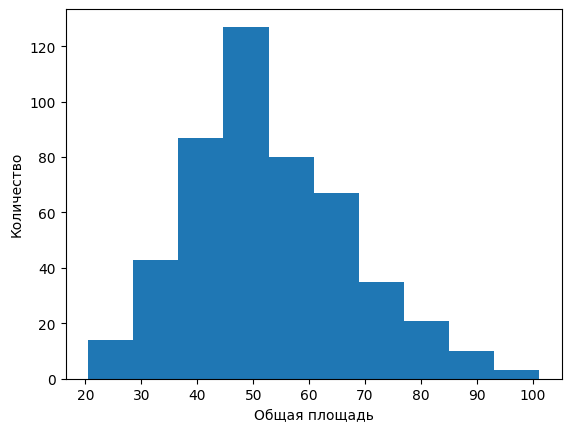

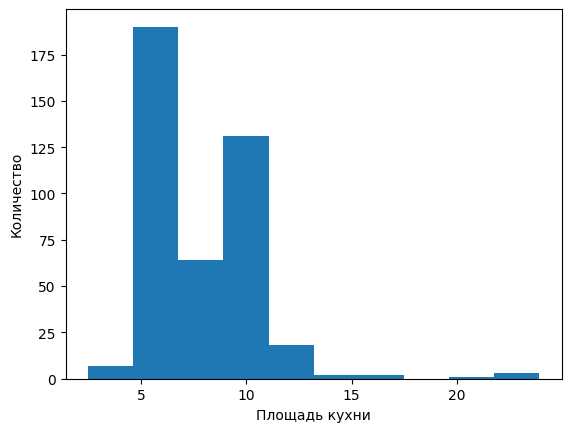

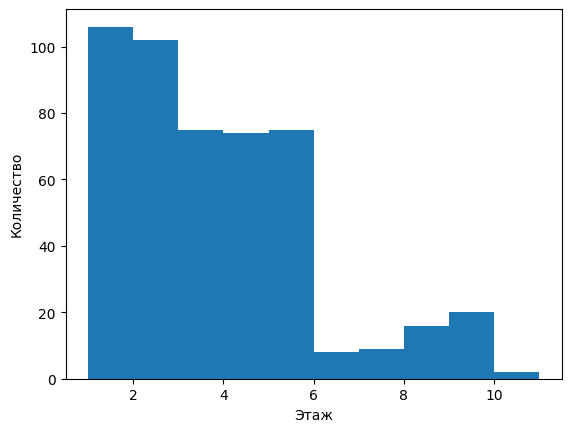

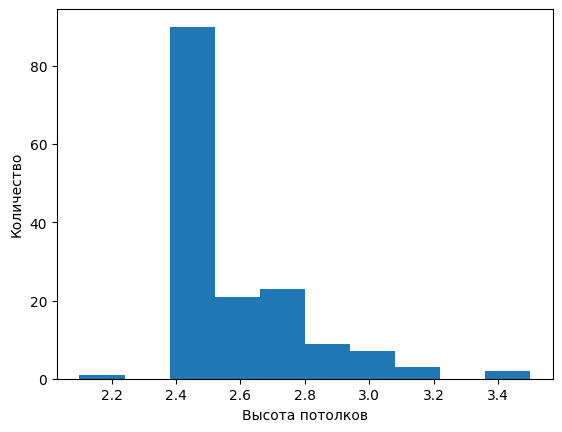

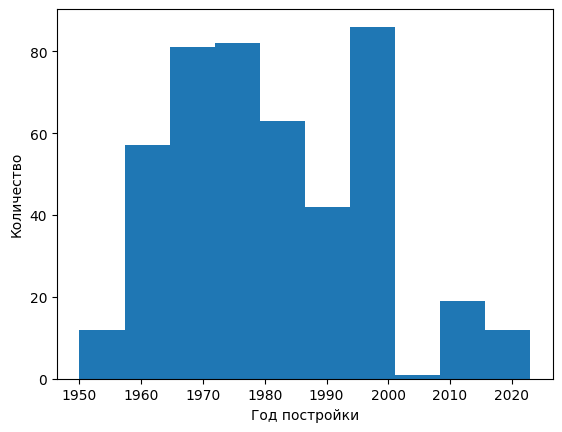

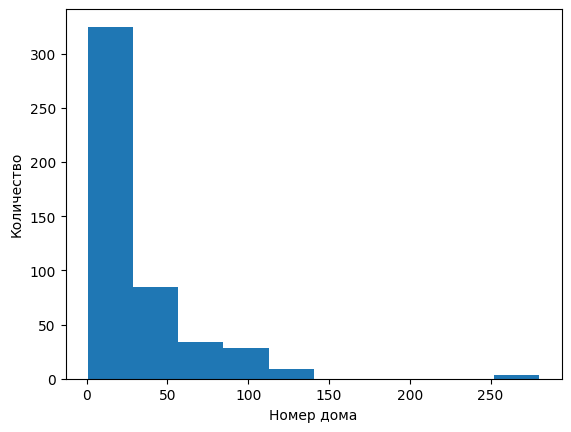

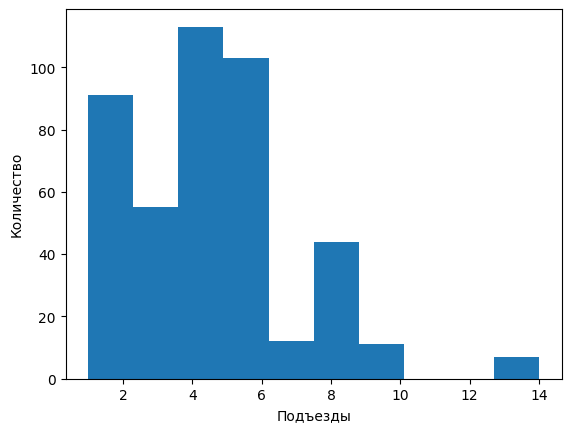

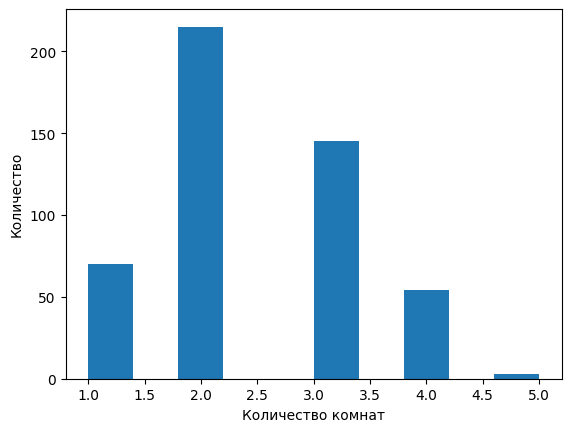

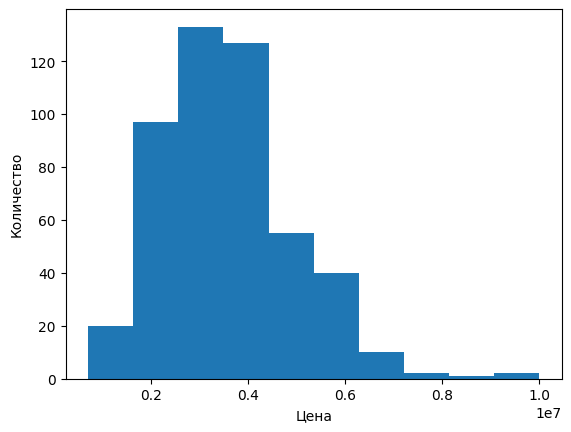

In [4]:
for col in num_columns + [target]:
    plt.figure()
    plt.hist(train[col])
    plt.xlabel(col)
    plt.ylabel('Количество')

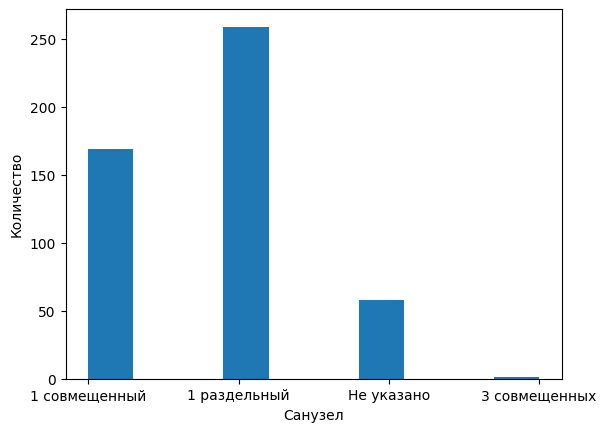

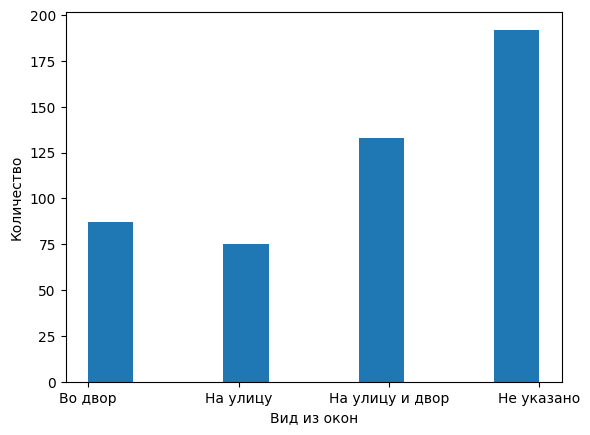

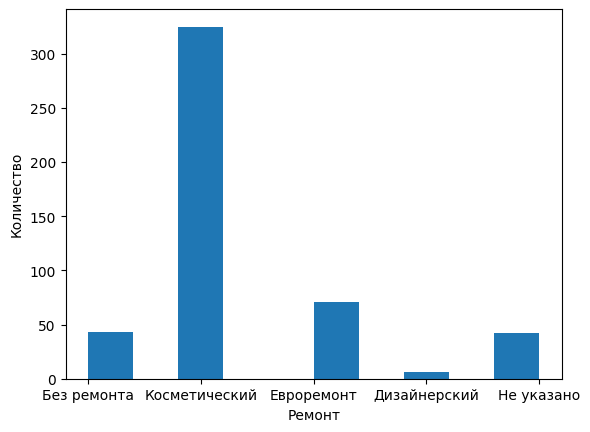

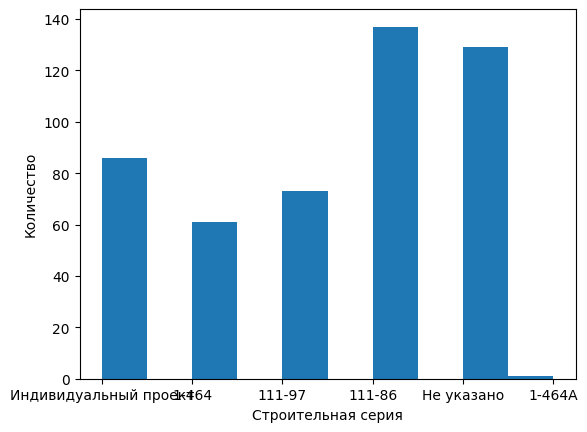

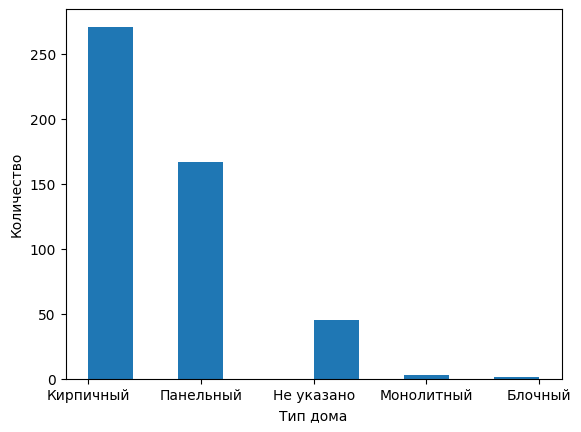

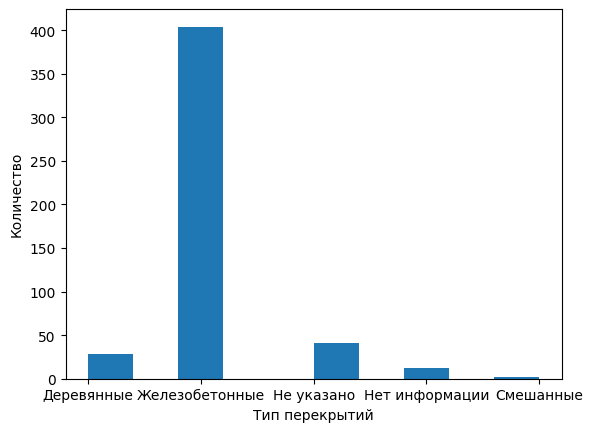

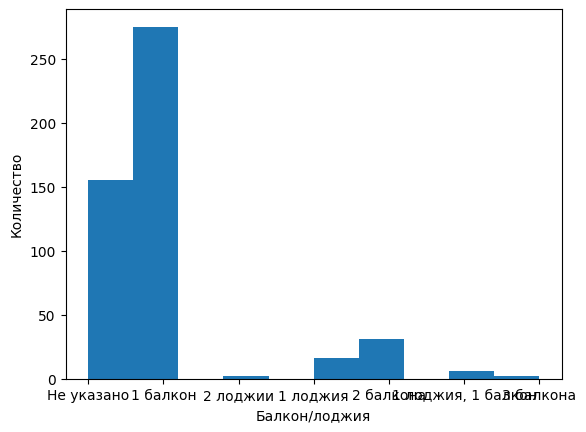

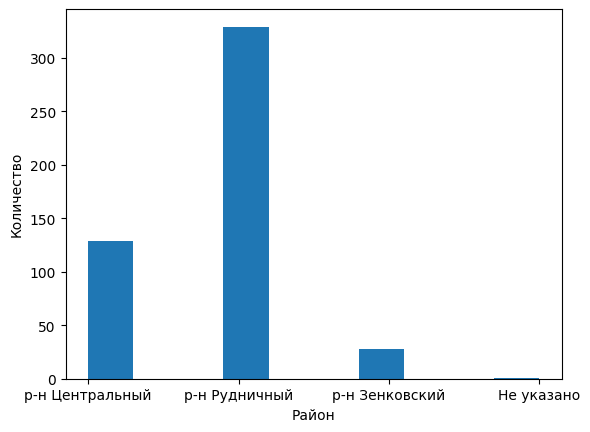

In [5]:
for col in cat_columns:
    plt.figure()
    plt.hist(train[col])
    plt.xlabel(col)
    plt.ylabel('Количество')

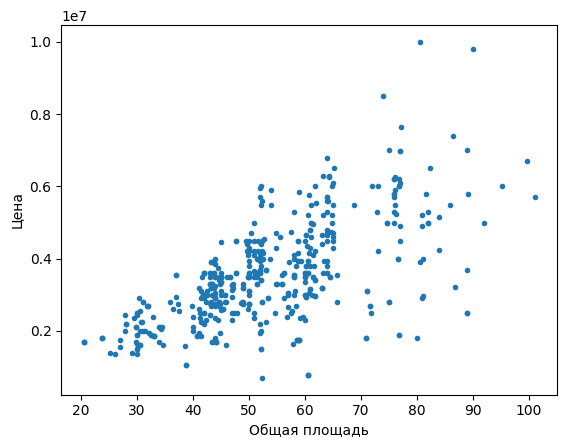

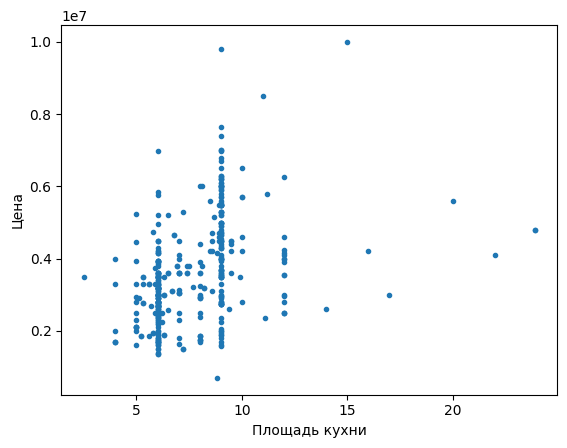

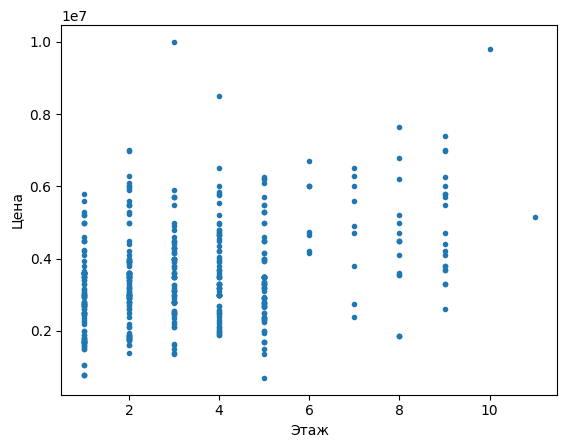

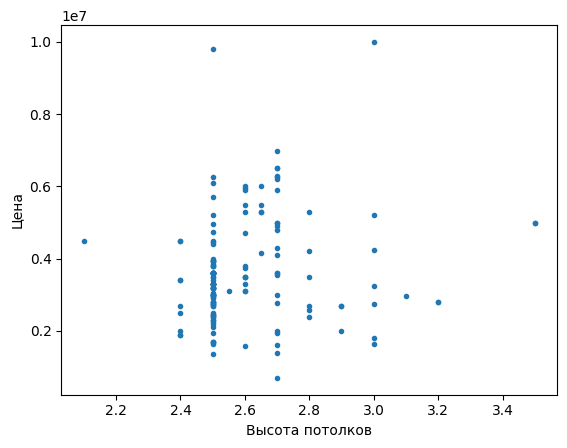

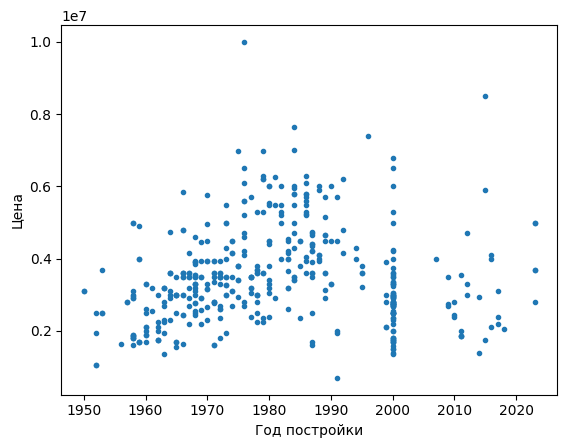

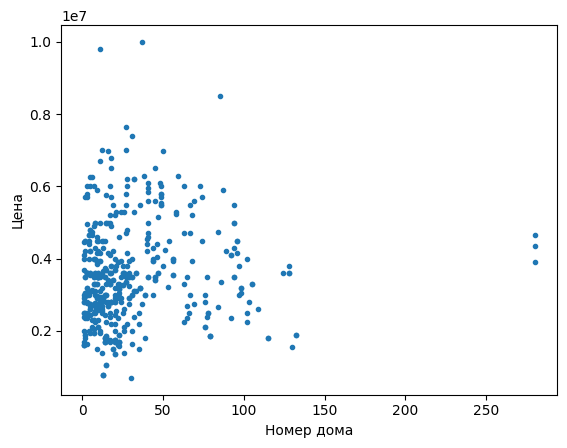

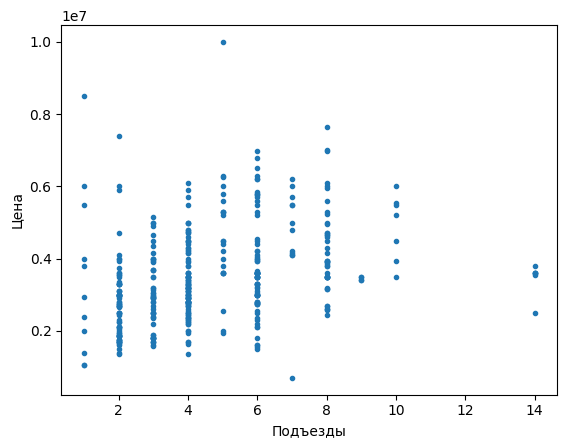

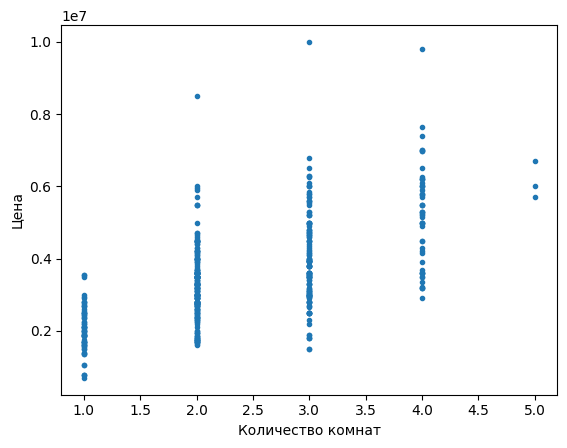

In [6]:
for col in num_columns:
    plt.figure()
    plt.plot(train[col], train[target], '.')
    plt.xlabel(col)
    plt.ylabel(target)

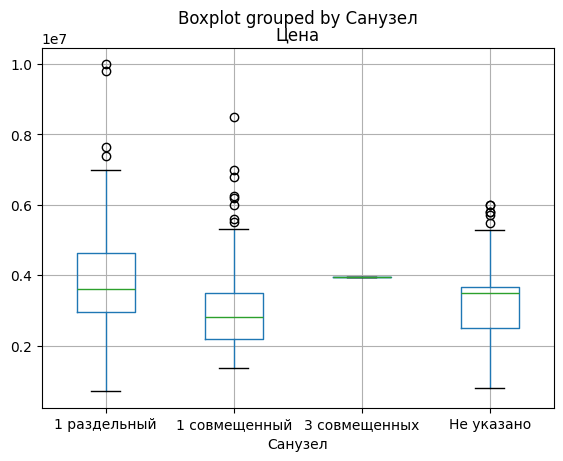

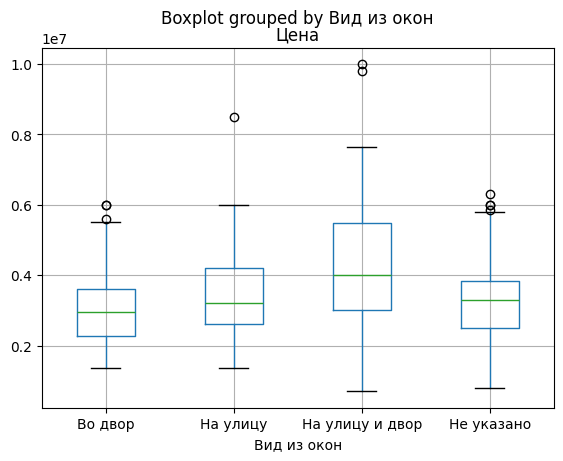

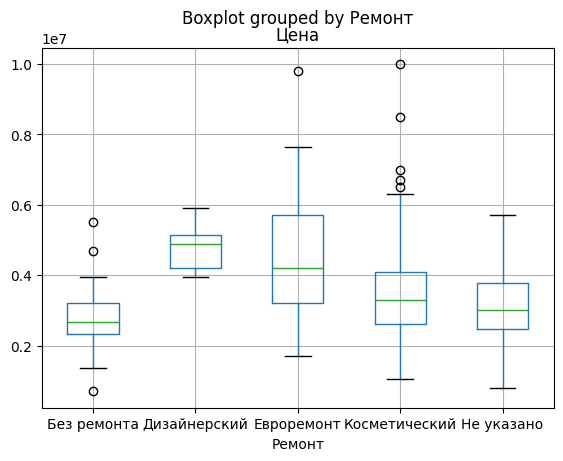

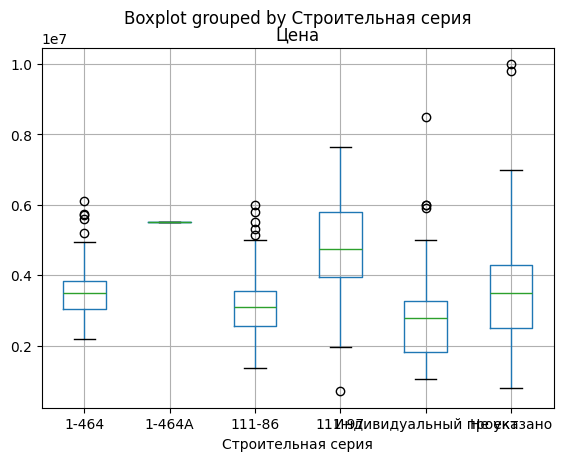

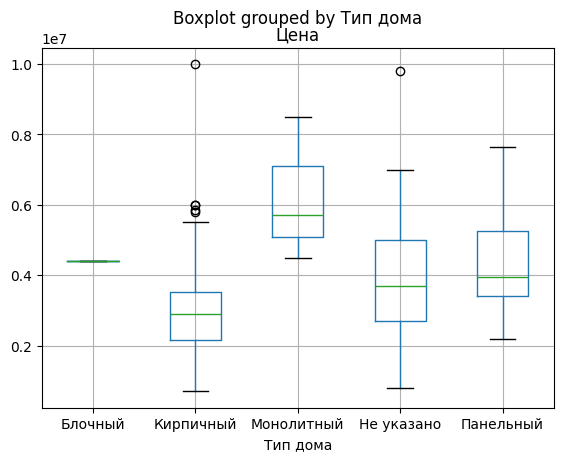

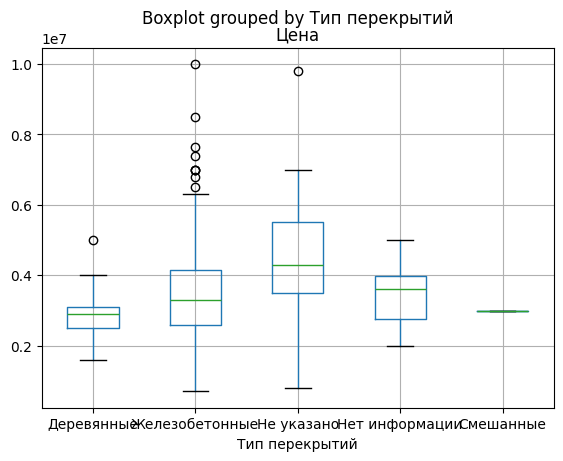

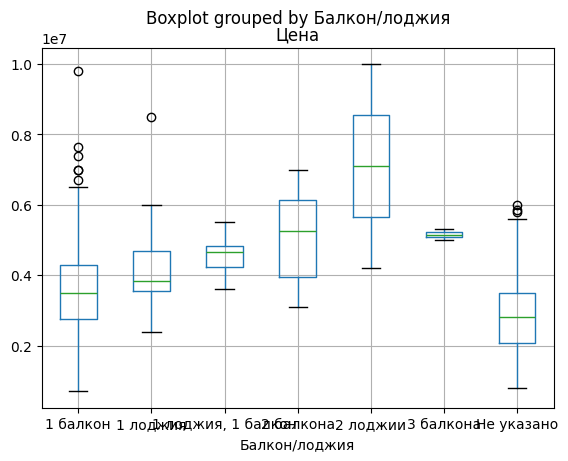

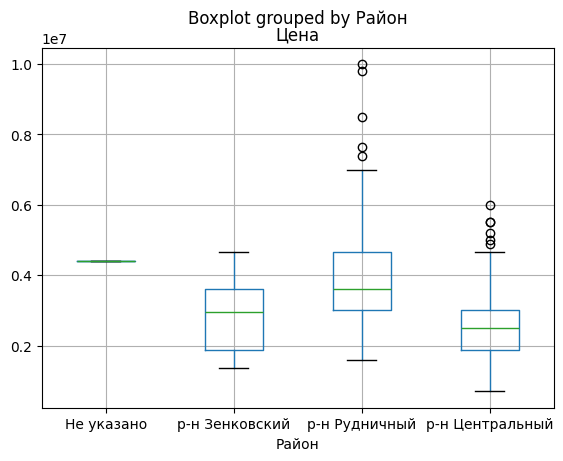

In [7]:
for col in cat_columns:
    train.boxplot(by=col, column=[target])

In [8]:
class TargetMeanEncoder:
    def __init__(self):
        self.maps = dict()
    
    def fit(self, df, col):
        self.maps[col] = df.groupby(col)[target].mean().to_dict()

    def transform(self, df, col):
        df['%s_target_mean' % col] = df[col].map(self.maps[col])
        return df

    def fit_transform(self, df, col):
        self.fit(df, col)
        return self.transform(df, col)


encoder = TargetMeanEncoder()

for col in cat_columns:
    train = encoder.fit_transform(train, col)

cat_target_mean_columns = [col for col in train.columns if '_target_mean' in col]

In [9]:
selected_features = num_columns + cat_target_mean_columns

<Axes: >

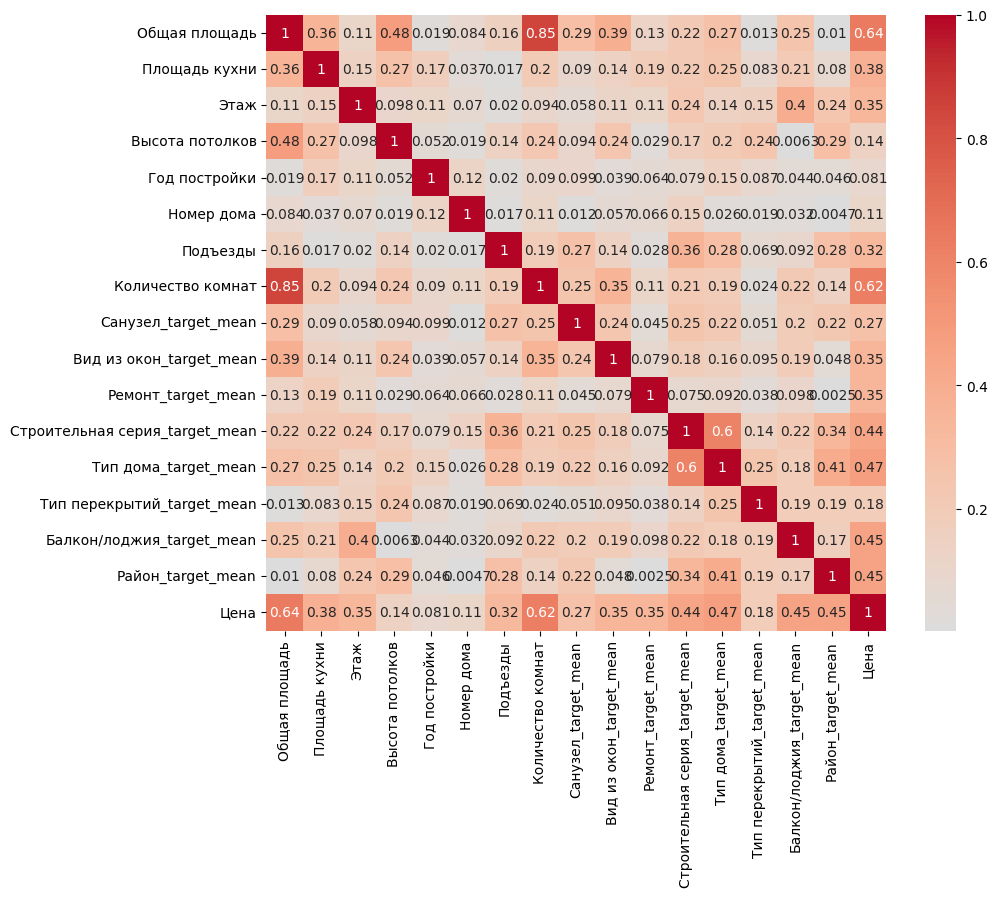

In [10]:
correlation_matrix = train[selected_features + [target]].corr()
correlation_matrix = np.abs(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

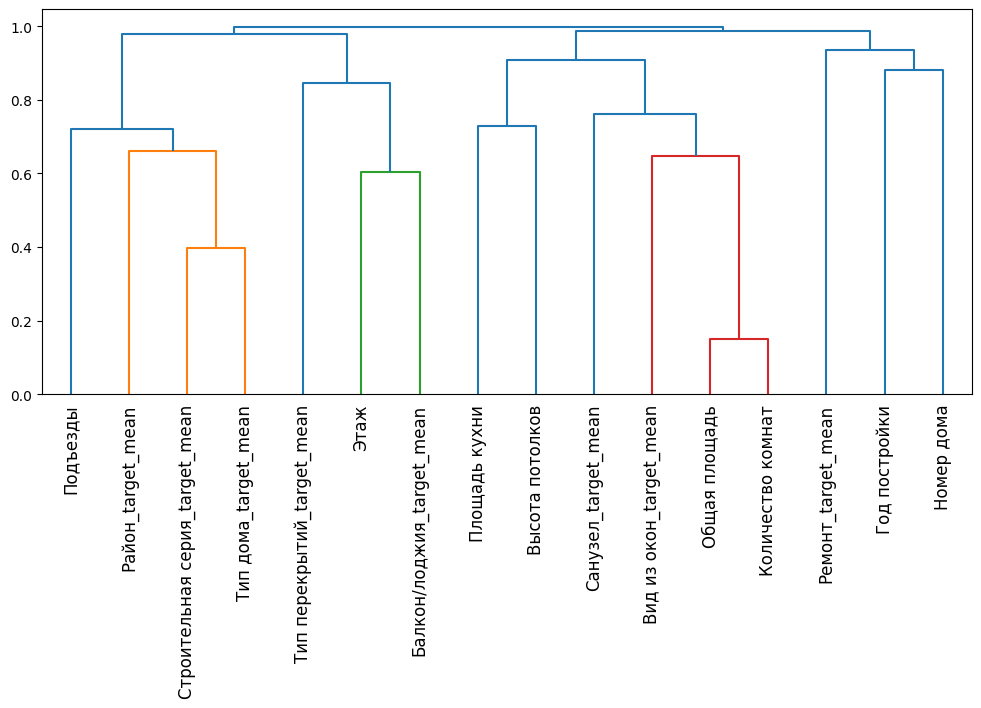

In [11]:
plt.figure(figsize=(12,5))
dissimilarity = 1 - abs(correlation_matrix.values[:-1, :-1])
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, labels=selected_features, orientation='top', leaf_rotation=90);

In [16]:
clusters = fcluster(Z, t=0.9, criterion='distance')

fuatures = dict()
for cls in set(clusters):
    best_corr = -1
    feature = ""
    for i in range(len(clusters)):
        if clusters[i] == cls:
            if correlation_matrix.values[i, -1] > best_corr:
                best_corr = np.abs(correlation_matrix.values[i, -1])
                feature = selected_features[i]
    fuatures[feature] = best_corr
    # print(cls, feature, best_corr)
fuatures = dict(sorted(fuatures.items(), key=lambda item: item[1], reverse=True))
fuatures

{'Общая площадь': np.float64(0.6369282163266735),
 'Тип дома_target_mean': np.float64(0.47201760190075465),
 'Балкон/лоджия_target_mean': np.float64(0.44986605357964304),
 'Площадь кухни': np.float64(0.3814207563791111),
 'Ремонт_target_mean': np.float64(0.347057970316222),
 'Номер дома': np.float64(0.10570588630585526)}